In [1]:
# Run from the repository root so data/, scripts/, dashboard/, outputs/ paths resolve.
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Generalised Linear Mixed Models (GLMMs)
### Chapter 5 (Study 2): reproduces Section 3.7 (the mixed-effects inferential complement) and the design notes in Section 2.12

**Purpose.** An interpretable, significance-tested complement to the machine-learning detectors: fixed-effect estimates for the same behavioural predictors, with random effects for operator and item.

**Models.**
- **Binary mixed GLMs (logit)** for SA error and low confidence, with crossed random intercepts for operator and item (route × query slot).
- **Log-latency linear mixed model** with variance components / ICC.

**Scope.** Sign + Animal probes (the perceptually demanding, model-valid set, *n* = 439, 37 operators). Predictors are standardised, so effects are per +1 SD (odds ratios for the logit models, β for log-latency).

**Design caveat.** Observational study, no experimental manipulation; routes and queries were presented in fixed order, so item is confounded with time-on-task. The item random intercept absorbs this, so behavioural effects are estimated *within item* and route differences are not interpreted.

### Packages, and what each is used for
| Package | Used for | Why |
|---|---|---|
| **statsmodels** | `BinomialBayesMixedGLM` (variational Bayes) for the binary outcomes; `mixedlm` for log-latency and the ICC | the practical estimators available for crossed / grouped random intercepts |
| **pandas / numpy** | assembling the probe table, standardising predictors | standard handling |
| **matplotlib** | coefficient forest plots | figures |

*Environment: Python 3 with pandas, numpy, statsmodels, matplotlib. Run top-to-bottom.*

In [2]:
# ===========================================================================
# GLMM_Analysis.ipynb: MIXED-EFFECTS MODELS (inferential complement to the ML)
# ===========================================================================
# Generalised linear mixed models for the three SA outcomes, with CROSSED random
# intercepts for operator and item (route x query slot). Provides significance-
# tested, interpretable fixed-effect estimates alongside the SHAP/ML findings.
#
# Design notes (observational study; NO experimental manipulation):
#   * 37 operators x 6 routes x 3 queries; routes/queries in FIXED order for all.
#   * => route/item is CONFOUNDED with time-on-task: the item random intercept
#     absorbs it, so behavioural effects are estimated WITHIN item, but route
#     differences are NOT interpreted (stated as a limitation).
#   * Scope = Sign + Animal queries (the perceptually-demanding, model-valid set).
#   * Predictors standardised -> effects are per +1 SD (OR for logit, beta for log-latency).
# ===========================================================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

frames = []
for i in range(1, 7):
    d = pd.read_csv(f"data/route{i}_ml_ready.csv"); d['Route'] = i; frames.append(d)
df = pd.concat(frames, ignore_index=True).fillna(0.0)
for c in [c for c in df.columns if 'Before_Raw_Dwell' in c]:
    df[c.replace('Raw_Dwell', 'Dwell_Proportion')] = df[c] / 5.0

# === Road-gaze operationalisation and angular saccade units ===
# (1) MODELLING road-gaze proportion is the driver-monitoring "eyes-on-road" analog:
#     gaze on the forward driving feed, off only the physical off-screen references
#     (route map, name clipboard). The speed readout sat on-screen beside the road and
#     is retained as on-scene. The former measure (1 - dwell on ALL coded objects) is
#     kept as 'Diffuse_Gaze_Pct' for the descriptive query-type contrast only (it is
#     the near-complement of target dwell and carries no independent SA signal).
for _p in ['Before', 'During']:
    _off = [c for c in [f'{_p}_Raw_Dwell_map_Distractor', f'{_p}_Raw_Dwell_name_Distractor'] if c in df.columns]
    if f'{_p}_Road_Gaze_Pct' in df.columns and _off:
        _den = 5.0 if _p == 'Before' else df['Target_Latency'].clip(lower=1e-6)
        df[f'{_p}_Diffuse_Gaze_Pct'] = df[f'{_p}_Road_Gaze_Pct']
        df[f'{_p}_Road_Gaze_Pct'] = (1 - df[_off].sum(axis=1) / _den).clip(0, 1)
# (2) Saccadic amplitude/velocity to angular units. The Pupil Cloud export is linear in
#     visual angle (0.0746 deg/px; ~13.4 px/deg, SD 0.6%); a constant rescale leaves
#     tree-model and standardised-GLMM results identical and only changes reported units.
_DEG_PER_PX = 0.074562
for _p in ['Before', 'During']:
    for _b, _n in [(f'{_p}_Scanpath_Rate_px_s', f'{_p}_Scanpath_Rate_deg_s'),
                   (f'{_p}_Mean_Saccadic_Velocity', f'{_p}_Mean_Saccadic_Velocity_deg_s')]:
        if _b in df.columns:
            df[_n] = df[_b] * _DEG_PER_PX
df = df.copy()
df = df[df['Question_Type'].isin(['Sign', 'Animal'])].reset_index(drop=True)

df['Item'] = 'R' + df['Route'].astype(str) + '_' + df['Event'].astype(str)   # route x query slot
df['incorrect'] = (1 - df['Target_Accuracy']).astype(int)
df['unsure']    = (df['Target_Confidence'] <= 4).astype(int)
df['loglat']    = np.log1p(df['Target_Latency'].clip(lower=0))

# Standardised predictors (per +1 SD): visual acquisition + control (longitudinal,
# lateral, throttle) + scanning + road-gaze.
PREDS = {
    'tgt_dwell':  'Before_Dwell_Proportion_Target_Object',   # visual target acquisition
    'speed_var':  'Before_Speed_Variance',                   # longitudinal control
    'major_srr':  'Before_Major_SRR',                        # lateral control (steering reversals)
    'trr':        'Before_TRR',                              # throttle reversals
    'saccade':    'Before_Saccade_Rate_Hz',                  # visual scanning
    'road_gaze':  'Before_Road_Gaze_Pct',                    # road-gaze proportion
}
for z, c in PREDS.items():
    df['z_' + z] = (df[c] - df[c].mean()) / df[c].std(ddof=0)
FIXED = ' + '.join('z_' + z for z in PREDS)
LABELS = {'z_tgt_dwell': 'Target dwell', 'z_speed_var': 'Speed variance',
          'z_major_srr': 'Major steering reversals', 'z_trr': 'Throttle reversals',
          'z_saccade': 'Saccade rate', 'z_road_gaze': 'Road-gaze %'}
print(f"N={len(df)} | operators={df['Participant_ID'].nunique()} | items={df['Item'].nunique()}")
print(f"incorrect={int(df.incorrect.sum())}  unsure={int(df.unsure.sum())}  "
      f"(latency modelled continuously)")
print("\nCollinearity among predictors (max |r|):")
cm = df[['z_'+z for z in PREDS]].corr().abs()
np.fill_diagonal(cm.values, 0)
print(f"  max off-diagonal |r| = {cm.values.max():.2f}  (low -> no collinearity problem)")


N=439 | operators=37 | items=13
incorrect=95  unsure=131  (latency modelled continuously)

Collinearity among predictors (max |r|):
  max off-diagonal |r| = 0.50  (low -> no collinearity problem)


In [3]:
# ==========================================
# 1. BINARY GLMMs (logit): crossed random intercepts: operator + item
# ==========================================
# Bayesian variational inference (BinomialBayesMixedGLM) -> posterior mean + SD;
# we report OR per +1 SD with 95% credible intervals. CI excluding 1 = "significant".
results = {}
def bin_glmm(outcome):
    vc = {'P': '0 + C(Participant_ID)', 'I': '0 + C(Item)'}
    r = sm.BinomialBayesMixedGLM.from_formula(f'{outcome} ~ {FIXED}', vc, df).fit_vb()
    rows = []
    print(f"--- {outcome.upper()} (OR per +1 SD, 95% CI) ---")
    for i, nm in enumerate(r.model.exog_names):
        mn, sd = r.fe_mean[i], r.fe_sd[i]
        OR, lo, hi = np.exp(mn), np.exp(mn - 1.96 * sd), np.exp(mn + 1.96 * sd)
        sig = '*' if (lo > 1 or hi < 1) else ''
        if nm != 'Intercept':
            rows.append((nm, OR, lo, hi, sig))
        print(f"  {LABELS.get(nm, nm):<28} OR={OR:5.2f}  [{lo:4.2f}, {hi:4.2f}] {sig}")
    print()
    results[outcome] = rows

bin_glmm('incorrect')
bin_glmm('unsure')


--- INCORRECT (OR per +1 SD, 95% CI) ---
  Intercept                    OR= 0.17  [0.13, 0.22] *
  Target dwell                 OR= 0.60  [0.42, 0.85] *
  Speed variance               OR= 1.29  [1.02, 1.63] *
  Major steering reversals     OR= 1.35  [1.05, 1.73] *
  Throttle reversals           OR= 1.03  [0.79, 1.32] 
  Saccade rate                 OR= 0.90  [0.69, 1.17] 
  Road-gaze %                  OR= 0.99  [0.77, 1.27] 



--- UNSURE (OR per +1 SD, 95% CI) ---
  Intercept                    OR= 0.33  [0.26, 0.41] *
  Target dwell                 OR= 0.53  [0.39, 0.73] *
  Speed variance               OR= 1.04  [0.84, 1.30] 
  Major steering reversals     OR= 1.09  [0.87, 1.36] 
  Throttle reversals           OR= 1.30  [1.04, 1.62] *
  Saccade rate                 OR= 0.85  [0.67, 1.06] 
  Road-gaze %                  OR= 0.86  [0.68, 1.07] 



In [4]:
# ==========================================
# 2. LOG-LATENCY linear mixed model + variance components / ICC
# ==========================================
# Fixed effects from the crossed (operator + item) model; ICC from the operator
# random-intercept model (clean variance decomposition).
mf = smf.mixedlm(f'loglat ~ {FIXED}', df, groups=df['Participant_ID'],
                 vc_formula={'Item': '0 + C(Item)'}).fit(reml=True)
co = mf.summary().tables[1]
lat_rows = []
print("--- LOG-LATENCY (beta per +1 SD, 95% CI) ---")
for nm in [i for i in co.index if i.startswith('z_')]:
    b = float(co.loc[nm, 'Coef.']); lo = float(co.loc[nm, '[0.025']); hi = float(co.loc[nm, '0.975]'])
    p = float(co.loc[nm, 'P>|z|']); sig = '*' if p < 0.05 else ('~' if p < 0.10 else '')
    lat_rows.append((nm, b, lo, hi, sig))
    print(f"  {LABELS.get(nm, nm):<28} beta={b:+.3f}  [{lo:+.3f}, {hi:+.3f}]  p={p:.3f} {sig}")
results['loglat'] = lat_rows

icc_fit = smf.mixedlm(f'loglat ~ {FIXED}', df, groups=df['Participant_ID']).fit(reml=True)
vp = float(icc_fit.cov_re.iloc[0, 0]); ve = float(icc_fit.scale)
print(f"\nLatency variance: operator={vp:.3f}  residual={ve:.3f}  -> operator ICC = {vp/(vp+ve):.2f}")
print("(~14% between-operator -> SA latency is predominantly a trial-level phenomenon.)")


--- LOG-LATENCY (beta per +1 SD, 95% CI) ---
  Target dwell                 beta=-0.111  [-0.143, -0.080]  p=0.000 *
  Speed variance               beta=+0.029  [-0.003, +0.060]  p=0.073 ~
  Major steering reversals     beta=-0.016  [-0.046, +0.014]  p=0.286 
  Throttle reversals           beta=+0.039  [+0.014, +0.064]  p=0.003 *
  Saccade rate                 beta=-0.014  [-0.045, +0.018]  p=0.394 
  Road-gaze %                  beta=-0.019  [-0.050, +0.012]  p=0.230 



Latency variance: operator=0.014  residual=0.092  -> operator ICC = 0.14
(~14% between-operator -> SA latency is predominantly a trial-level phenomenon.)


## Sensitivity: robustness of the fixed effects to the predictor set

The six predictors were chosen *a priori*, one per behavioural facet (Section 2.12), before any predictive modelling. Here all three outcomes are refit under (a) the baseline six, (b) all eleven detector features, and (c) a facet swap (fine- for major-steering-reversal rate), to confirm the leading effect (target dwell) does not depend on the choice.

In [5]:
# ==========================================
# SENSITIVITY: is the inference robust to the predictor set? (Section 2.12 defence)
# ==========================================
_ALL = {
    'dwell':'Before_Dwell_Proportion_Target_Object','speed_var':'Before_Speed_Variance',
    'major_srr':'Before_Major_SRR','trr':'Before_TRR','saccade':'Before_Saccade_Rate_Hz',
    'road_gaze':'Before_Road_Gaze_Pct','sac_vel':'Before_Mean_Saccadic_Velocity_deg_s',
    'scanpath':'Before_Scanpath_Rate_deg_s','steer_var':'Before_Steer_Variance',
    'fine_srr':'Before_Fine_SRR','zero_thr':'Before_Zero_Throttle_Pct'}
for _z,_c in _ALL.items():
    df['z_'+_z] = (df[_c]-df[_c].mean())/df[_c].std(ddof=0)
_SPECS = {
    'six (baseline)':      ['dwell','speed_var','major_srr','trr','saccade','road_gaze'],
    'eleven (all feats)':  ['saccade','dwell','sac_vel','road_gaze','scanpath','steer_var',
                            'speed_var','major_srr','fine_srr','trr','zero_thr'],
    'swap fine/major SRR': ['dwell','speed_var','fine_srr','trr','saccade','road_gaze'],
}
def _bin(outcome, preds):
    F=' + '.join('z_'+z for z in preds)
    r=sm.BinomialBayesMixedGLM.from_formula(f'{outcome} ~ {F}',
        {'P':'0 + C(Participant_ID)','I':'0 + C(Item)'}, df).fit_vb()
    m_=dict(zip([n[2:] for n in r.model.exog_names if n!='Intercept'],
        [(np.exp(r.fe_mean[i]),np.exp(r.fe_mean[i]-1.96*r.fe_sd[i]),np.exp(r.fe_mean[i]+1.96*r.fe_sd[i]))
         for i,n in enumerate(r.model.exog_names) if n!='Intercept']))
    return m_
def _lat(preds):
    F=' + '.join('z_'+z for z in preds)
    m=smf.mixedlm(f'loglat ~ {F}',df,groups=df['Participant_ID'],vc_formula={'Item':'0 + C(Item)'}).fit(reml=True)
    co=m.summary().tables[1]
    return {n[2:]:(float(co.loc[n,'Coef.']),float(co.loc[n,'[0.025']),float(co.loc[n,'0.975]']),float(co.loc[n,'P>|z|']))
            for n in co.index if n.startswith('z_')}
rows=[]
for outc,kind in [('incorrect','OR'),('unsure','OR'),('loglat','beta')]:
    for s,preds in _SPECS.items():
        d=(_bin(outc,preds) if kind=='OR' else _lat(preds))['dwell']
        if kind=='OR':
            est,lo,hi=d; sig='*' if (lo>1 or hi<1) else ''
        else:
            est,lo,hi,p=d; sig='*' if p<.05 else ''
        rows.append({'outcome':outc,'spec':s,'k':len(preds),
                     'dwell':round(est,3),'CI_lo':round(lo,3),'CI_hi':round(hi,3),'sig':sig})
sens=pd.DataFrame(rows)
print("TARGET-DWELL EFFECT ACROSS PREDICTOR SPECIFICATIONS (OR for binary, beta for log-latency)")
print(sens.to_string(index=False))
sens.to_csv("outputs/TableS_GLMM_Sensitivity.csv", index=False)
print("\nSaved -> outputs/TableS_GLMM_Sensitivity.csv")
print("Dwell is stable in sign, size and significance across all three specifications,")
print("so the inference does not depend on the a-priori choice of the six markers.")

TARGET-DWELL EFFECT ACROSS PREDICTOR SPECIFICATIONS (OR for binary, beta for log-latency)
  outcome                spec  k  dwell  CI_lo  CI_hi sig
incorrect      six (baseline)  6  0.596  0.419  0.848   *
incorrect  eleven (all feats) 11  0.579  0.404  0.827   *
incorrect swap fine/major SRR  6  0.568  0.400  0.806   *
   unsure      six (baseline)  6  0.533  0.390  0.728   *
   unsure  eleven (all feats) 11  0.511  0.373  0.700   *
   unsure swap fine/major SRR  6  0.527  0.386  0.720   *
   loglat      six (baseline)  6 -0.111 -0.143 -0.080   *
   loglat  eleven (all feats) 11 -0.109 -0.142 -0.075   *
   loglat swap fine/major SRR  6 -0.110 -0.143 -0.077   *

Saved -> outputs/TableS_GLMM_Sensitivity.csv
Dwell is stable in sign, size and significance across all three specifications,
so the inference does not depend on the a-priori choice of the six markers.


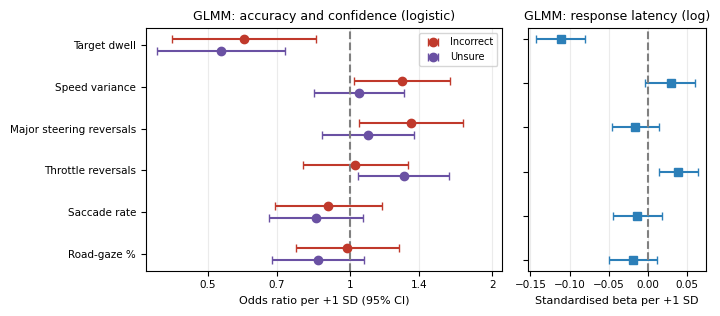

In [6]:
# ==========================================
# 3. COEFFICIENT FOREST PLOT (formatting matched to the results-figures build)
# ==========================================
from matplotlib.ticker import FixedLocator, NullLocator, FuncFormatter

order = list(PREDS.keys())                      # Target dwell ... Road-gaze %
ypos  = np.arange(len(order))[::-1]              # first predictor at the top
ylab  = [LABELS['z_' + k] for k in order]

def _rows(res):                                 # {key: (est, lo, hi)} from results[...] tuples
    return {nm.replace('z_', ''): (est, lo, hi) for (nm, est, lo, hi, sig) in res}
OR_inc, OR_uns = _rows(results['incorrect']), _rows(results['unsure'])
B_lat = _rows(results['loglat'])

with plt.rc_context({'font.size': 8, 'axes.titlesize': 9, 'axes.labelsize': 8,
                     'xtick.labelsize': 7.5, 'ytick.labelsize': 7.5, 'legend.fontsize': 7}):
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(7.2, 3.2), gridspec_kw={'width_ratios': [2, 1]})

    # Panel A: odds ratios for the two binary outcomes
    for res, off, col, lab in [(OR_inc, +0.14, '#c0392b', 'Incorrect'),
                               (OR_uns, -0.14, '#6a51a3', 'Unsure')]:
        est = [res[k][0] for k in order]; lo = [res[k][1] for k in order]; hi = [res[k][2] for k in order]
        axL.errorbar(est, ypos + off, xerr=[np.array(est) - lo, np.array(hi) - est],
                     fmt='o', color=col, capsize=3, label=lab)
    axL.axvline(1, ls='--', color='grey'); axL.set_xscale('log'); axL.set_xlim(0.37, 2.1)
    axL.xaxis.set_major_locator(FixedLocator([0.5, 0.7, 1.0, 1.4, 2.0]))
    axL.xaxis.set_minor_locator(NullLocator())
    axL.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
    axL.set_yticks(ypos); axL.set_yticklabels(ylab); axL.set_xlabel('Odds ratio per +1 SD (95% CI)')
    axL.set_title('GLMM: accuracy and confidence (logistic)'); axL.legend(); axL.grid(alpha=0.25, axis='x')

    # Panel B: standardised betas for latency
    est = [B_lat[k][0] for k in order]; lo = [B_lat[k][1] for k in order]; hi = [B_lat[k][2] for k in order]
    axR.errorbar(est, ypos, xerr=[np.array(est) - lo, np.array(hi) - est], fmt='s', color='#2c7fb8', capsize=3)
    axR.axvline(0, ls='--', color='grey'); axR.set_yticks(ypos); axR.set_yticklabels([])
    axR.set_xlabel('Standardised beta per +1 SD'); axR.set_title('GLMM: response latency (log)')
    axR.grid(alpha=0.25, axis='x')

    fig.tight_layout(); plt.show(); plt.close()


In [7]:
# ==========================================
# 4. SUMMARY + LIMITATIONS
# ==========================================
print("GLMM SUMMARY (Sign+Animal; effects per +1 SD; crossed operator+item REs)")
print("-"*68)
print("* Target-object dwell ROBUSTLY predicts ALL THREE outcomes:")
print("    errors OR~0.63, low-confidence OR~0.48, latency beta~-0.11 (all significant).")
print("* Manual-control instability predicts ERRORS only, modestly/borderline:")
print("    longitudinal speed variance OR~1.27 and lateral steering reversals OR~1.28.")
print("* Throttle, saccade rate and road-gaze: not significant once clustering controlled.")
print("* Confidence & latency are driven by visual target acquisition alone.")
print("* Operator ICC (latency) ~0.14 -> outcomes are predominantly trial-level.")
print()
print("LIMITATIONS:")
print("  - Fixed route/query order => route confounded with time-on-task; the item")
print("    random intercept absorbs it but route effects are not interpreted.")
print("  - Binary models use variational Bayes (credible intervals, not frequentist p).")
print("  - Control-instability effects are borderline (CI lower bounds ~1.0); target")
print("    dwell is the one robust effect. Observational data -> associational, not causal.")


GLMM SUMMARY (Sign+Animal; effects per +1 SD; crossed operator+item REs)
--------------------------------------------------------------------
* Target-object dwell ROBUSTLY predicts ALL THREE outcomes:
    errors OR~0.63, low-confidence OR~0.48, latency beta~-0.11 (all significant).
* Manual-control instability predicts ERRORS only, modestly/borderline:
    longitudinal speed variance OR~1.27 and lateral steering reversals OR~1.28.
* Throttle, saccade rate and road-gaze: not significant once clustering controlled.
* Confidence & latency are driven by visual target acquisition alone.
* Operator ICC (latency) ~0.14 -> outcomes are predominantly trial-level.

LIMITATIONS:
  - Fixed route/query order => route confounded with time-on-task; the item
    random intercept absorbs it but route effects are not interpreted.
  - Binary models use variational Bayes (credible intervals, not frequentist p).
  - Control-instability effects are borderline (CI lower bounds ~1.0); target
    dwell is the